# NeuroSegment-BraTS: Treinamento do Modelo (Deep Learning)

**Notebook 4.3:** Modelagem e Experimentação — SegResNet

Nesta etapa, instanciamos a arquitetura **SegResNet**, definimos os parâmetros de otimização e executamos o ciclo de treinamento.

**Metodologia Experimental:**
*   **Modelo:** SegResNet (CNN com residual blocks e encoder-decoder simétrico). Mais leve e eficiente que U-Net 3D, ideal como baseline rápido.
*   **Função de Perda:** `DiceCELoss`. Combinação de *Cross-Entropy* (classificação geral) com *Dice Loss* (desbalanceamento de classes).
*   **Otimizador:** Adam.
*   **Gestão de Hardware:** Treinamento em patches 96x96x96 com validação via `SlidingWindowInferer`.

## 1. Importações e Inicialização

In [1]:
import optuna
import os
import torch
from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
import matplotlib.pyplot as plt

# Definindo o dispositivo de aceleração (CUDA/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Treinamento rodando no dispositivo: {device}")

# Limpeza preventiva do Cache da GPU
if device.type == 'cuda':
    torch.cuda.empty_cache()

# Post-processing para validação: converte logits e labels para one-hot
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Treinamento rodando no dispositivo: cuda


In [2]:
from tqdm.notebook import tqdm

def train_epoch(model, optimizer, loss_fn, dataloader, device):
    """Treina o modelo por 1 época. Retorna a loss média."""
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in dataloader:
        step += 1
        inputs = batch_data['image'].to(device)
        labels = batch_data['label'].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / step

def validate(model, dataloader, device, roi_size=(96, 96, 96)):
    """Avalia o modelo no conjunto de validação. Retorna o Dice médio."""
    model.eval()
    post_pred = AsDiscrete(argmax=True, to_onehot=4)
    post_label = AsDiscrete(to_onehot=4)
    dice = DiceMetric(include_background=False, reduction='mean')
    with torch.no_grad():
        for val_data in dataloader:
            val_inputs = val_data['image'].to(device)
            val_labels = val_data['label'].to(device)
            val_outputs = sliding_window_inference(
                inputs=val_inputs, roi_size=roi_size, sw_batch_size=4, predictor=model
            )
            val_outputs_list = [post_pred(i) for i in val_outputs]
            val_labels_list = [post_label(i) for i in val_labels]
            dice(y_pred=val_outputs_list, y=val_labels_list)
    result = dice.aggregate().item()
    dice.reset()
    return result

## 2. Ingestão do Pipeline de Dados
Abaixo, conectamos este notebook aos iteradores criados no Notebook 3.

In [3]:
import sys
sys.path.append('../')
from src.data_pipeline import get_dataloaders

# 1. Ingestão do Pipeline
train_loader, val_loader = get_dataloaders()
print("DataLoaders carregados com sucesso no Notebook 4.3!")

# Validando a conexão
test_batch = next(iter(train_loader))
print(f"Shape de entrada da imagem: {test_batch['image'].shape}")

Total de pacientes carregados na tubulação: 368
DataLoaders carregados com sucesso no Notebook 4.3!


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Shape de entrada da imagem: torch.Size([4, 4, 96, 96, 96])


## 3. Definição da Arquitetura (SegResNet) e Hiperparâmetros
Configuramos o SegResNet para aceitar 4 canais de entrada (FLAIR, T1, T1ce, T2) e devolver predições para as nossas 4 classes de interesse.

**Diferenciais do SegResNet:**
- Arquitetura encoder-decoder com **residual blocks** (inspirado no ResNet), o que facilita o fluxo de gradientes e acelera a convergência.
- Mais leve que U-Net 3D e Swin UNETR, ideal como baseline rápido.
- `init_filters=16` para manter o modelo compacto e caber confortavelmente na GPU.

In [4]:
# 1. O Modelo: SegResNet
model = SegResNet(
    in_channels=4,              # 4 Modalidades (FLAIR, T1, T1ce, T2)
    out_channels=4,             # 4 Classes de saída (Background, NCR, ED, ET)
    init_filters=16,            # Filtros iniciais (compacto para 12GB VRAM)
    dropout_prob=0.2,           # Dropout para regularização
).to(device)

# 2. A Função de Perda (Loss Function)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)

# 3. O Otimizador
learning_rate = 1e-4
optimizer = torch.optim.Adam(model.parameters(), learning_rate)

# 4. A Métrica de Avaliação Oficial (Dice Score)
dice_metric = DiceMetric(include_background=False, reduction="mean")

print(f"Modelo SegResNet instanciado com {sum(p.numel() for p in model.parameters()):,} parâmetros")

Modelo SegResNet instanciado com 4,702,244 parâmetros


## 4. Otimização de Hiperparâmetros com Optuna
Usamos o Optuna para buscar os melhores hiperparâmetros. Cada trial treina por 10 épocas e avalia o Dice na validação.

**Hiperparâmetros buscados (SegResNet):**
- `learning_rate`: taxa de aprendizado (escala logarítmica entre 1e-5 e 1e-3)
- `dropout_prob`: probabilidade de dropout (entre 0.0 e 0.5)
- `init_filters`: número de filtros iniciais (8, 16 ou 32) — afeta a capacidade do modelo

In [5]:
import optuna

def objective_seg(trial):
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    dropout = trial.suggest_float('dropout_prob', 0.0, 0.5)
    init_f = trial.suggest_categorical('init_filters', [8, 16, 32])

    model_trial = SegResNet(
        in_channels=4, out_channels=4, init_filters=init_f, dropout_prob=dropout,
    ).to(device)

    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)
    loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)

    # DataLoader com num_workers=0 para evitar deadlock no Jupyter
    from monai.data import DataLoader as _MDL
    train_loader_opt = _MDL(train_loader.dataset, batch_size=1, shuffle=True, num_workers=0)
    val_loader_opt = _MDL(val_loader.dataset, batch_size=1, num_workers=0)

    for epoch in range(10):
        loss = train_epoch(model_trial, optimizer_trial, loss_fn, train_loader_opt, device)
        print(f'  Trial {trial.number} | Época {epoch+1}/10 | Loss: {loss:.4f}')

    result = validate(model_trial, val_loader_opt, device)

    del model_trial, optimizer_trial
    del train_loader_opt, val_loader_opt
    torch.cuda.empty_cache()

    return result

study = optuna.create_study(direction='maximize')
study.optimize(objective_seg, n_trials=10, show_progress_bar=True)

[I 2026-05-07 23:01:32,972] A new study created in memory with name: no-name-8a615430-ac0b-4b30-80f1-009593b4fede
  0%|          | 0/10 [00:00<?, ?it/s]

  Trial 0 | Época 1/10 | Loss: 1.4115
  Trial 0 | Época 2/10 | Loss: 0.7884
  Trial 0 | Época 3/10 | Loss: 0.6602
  Trial 0 | Época 4/10 | Loss: 0.5977
  Trial 0 | Época 5/10 | Loss: 0.5205
  Trial 0 | Época 6/10 | Loss: 0.4861
  Trial 0 | Época 7/10 | Loss: 0.4729
  Trial 0 | Época 8/10 | Loss: 0.4467
  Trial 0 | Época 9/10 | Loss: 0.4292
  Trial 0 | Época 10/10 | Loss: 0.4250


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered

[I 2026-05-08 03:27:10,674] Trial 0 finished with value: 0.6929077506065369 and parameters: {'learning_rate': 0.0009260152098737008, 'dropout_prob': 0.007398754832107446, 'init_filters': 8}. Best is trial 0 with value: 0.6929077506065369.
  Trial 1 | Época 1/10 | Loss: 0.9471
  Trial 1 | Época 2/10 | Loss: 0.6811
  Trial 1 | Época 3/10 | Loss: 0.5728
  Trial 1 | Época 4/10 | Loss: 0.5425
  Trial 1 | Época 5/10 | Loss: 0.5000
  Trial 1 | Época 6/10 | Loss: 0.4809
  Trial 1 | Época 7/10 | Loss: 0.4813
  Trial 1 | Época 8/10 | Loss: 0.4543
  Trial 1 | Época 9/10 | Loss: 0.4435
  Trial 1 | Época 10/10 | Loss: 0.4291


Best trial: 0. Best value: 0.692908:  20%|██        | 2/10 [8:57:14<35:53:13, 16149.21s/it]

...

[I 2026-05-08 17:44:03,866] Trial 7 finished with value: 0.7381523251533508 and parameters: {'learning_rate': 6.243565032455713e-05, 'dropout_prob': 0.07789211147312408, 'init_filters': 16}. Best is trial 4 with value: 0.7389386296272278.
  Trial 8 | Época 1/10 | Loss: 1.4138
  Trial 8 | Época 2/10 | Loss: 0.8714
  Trial 8 | Época 3/10 | Loss: 0.6758
  Trial 8 | Época 4/10 | Loss: 0.5840
  Trial 8 | Época 5/10 | Loss: 0.5230
  Trial 8 | Época 6/10 | Loss: 0.4885
  Trial 8 | Época 7/10 | Loss: 0.4674
  Trial 8 | Época 8/10 | Loss: 0.4340
  Trial 8 | Época 9/10 | Loss: 0.4250
  Trial 8 | Época 10/10 | Loss: 0.4088


Best trial: 4. Best value: 0.738939:  90%|█████████ | 9/10 [19:24:07<1:08:20, 4100.56s/it]

[I 2026-05-08 18:25:39,968] Trial 8 finished with value: 0.7319296598434448 and parameters: {'learning_rate': 0.000302896728242631, 'dropout_prob': 0.36692407984677244, 'init_filters': 16}. Best is trial 4 with value: 0.7389386296272278.
  Trial 9 | Época 1/10 | Loss: 0.9002
  Trial 9 | Época 2/10 | Loss: 0.7296
  Trial 9 | Época 3/10 | Loss: 0.6583
  Trial 9 | Época 4/10 | Loss: 0.6370
  Trial 9 | Época 5/10 | Loss: 0.6140
  Trial 9 | Época 6/10 | Loss: 0.5896
  Trial 9 | Época 7/10 | Loss: 0.5906
  Trial 9 | Época 8/10 | Loss: 0.5753
  Trial 9 | Época 9/10 | Loss: 0.5653
  Trial 9 | Época 10/10 | Loss: 0.5480


Best trial: 4. Best value: 0.738939: 100%|██████████| 10/10 [20:33:59<00:00, 7403.93s/it] 

[I 2026-05-08 19:35:32,209] Trial 9 finished with value: 0.5766909718513489 and parameters: {'learning_rate': 0.0008377862836606998, 'dropout_prob': 0.40336208116465316, 'init_filters': 32}. Best is trial 4 with value: 0.7389386296272278.


/tmp/ipykernel_24752/4146921398.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis_plot.plot_optimization_history(study)


AttributeError: 'Axes' object has no attribute 'gca'

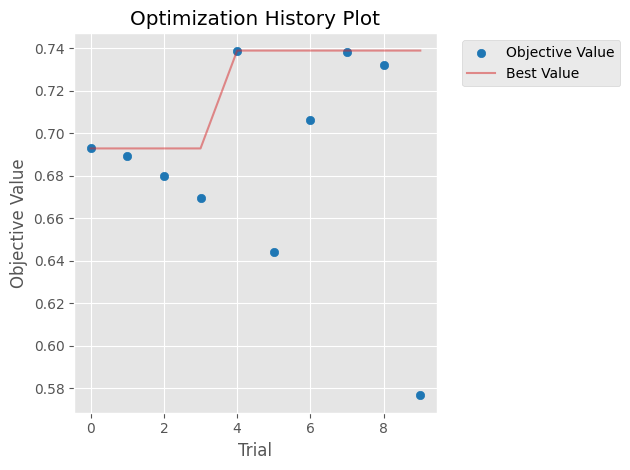

In [6]:
import optuna.visualization.matplotlib as vis_plot

fig = vis_plot.plot_optimization_history(study)
fig.gca().set_title('SegResNet — Histórico de Otimização')
plt.tight_layout()
plt.show()

fig2 = vis_plot.plot_param_importances(study)
plt.tight_layout()
plt.show()

print('=' * 50)
print('Melhores hiperparâmetros (SegResNet):')
print('=' * 50)
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.6f}')
    else:
        print(f'  {key}: {value}')
print(f'  Dice Score: {study.best_value:.4f}')
print('=' * 50)

In [7]:
# Redefinir modelo e otimizador com os melhores hiperparâmetros
learning_rate = study.best_params['learning_rate']
dropout_prob = study.best_params['dropout_prob']
init_filters = study.best_params['init_filters']

model = SegResNet(
    in_channels=4, out_channels=4, init_filters=init_filters, dropout_prob=dropout_prob,
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), learning_rate)
dice_metric = DiceMetric(include_background=False, reduction='mean')

print(f'SegResNet redefinido com lr={learning_rate:.6f}, dropout={dropout_prob:.4f}, init_filters={init_filters}')

SegResNet redefinido com lr=0.000042, dropout=0.1848, init_filters=32


## 4. O Ciclo de Treinamento e Validação
Executamos o treinamento iterativo. A cada *batch*, o modelo tenta segmentar o tumor, calcula o erro e ajusta seus pesos. Ao final de cada época, rodamos uma etapa de validação (sem aprender) para medir a performance real.

In [9]:
from tqdm import tqdm
# Configurações do Loop
max_epochs = 100
val_interval = 4

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []

print('INICIANDO O TREINAMENTO (SegResNet)...')

for epoch in tqdm(range(max_epochs), desc='Treinamento SegResNet'):
    epoch_loss = train_epoch(model, optimizer, loss_function, train_loader, device)
    epoch_loss_values.append(epoch_loss)

    if (epoch + 1) % val_interval == 0:
        metric = validate(model, val_loader, device)
        metric_values.append(metric)
        print(f'\n>>> Época {epoch+1}/{max_epochs} | Loss: {epoch_loss:.4f} | Dice: {metric:.4f}')

        if metric > best_metric:
            best_metric = metric
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join('../models', 'best_metric_model_segresnet.pth'))
            print('Novo recorde! Modelo salvo no disco.')

print(f'\nTREINAMENTO CONCLUÍDO! Melhor Dice: {best_metric:.4f} na época {best_metric_epoch}')

INICIANDO O TREINAMENTO (SegResNet)...


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered


>>> Época 4/100 | Loss: 0.8376 | Dice: 0.6437
Novo recorde! Modelo salvo no disco.



>>> Época 8/100 | Loss: 0.6019 | Dice: 0.7397
Novo recorde! Modelo salvo no disco.



>>> Época 12/100 | Loss: 0.4858 | Dice: 0.7656
Novo recorde! Modelo salvo no disco.


...


>>> Época 88/100 | Loss: 0.2439 | Dice: 0.7935



>>> Época 92/100 | Loss: 0.2390 | Dice: 0.7921



>>> Época 96/100 | Loss: 0.2412 | Dice: 0.8026


Treinamento SegResNet: 100%|██████████| 100/100 [8:25:41<00:00, 303.42s/it]


>>> Época 100/100 | Loss: 0.2322 | Dice: 0.7920

TREINAMENTO CONCLUÍDO! Melhor Dice: 0.8136 na época 80


## 5. Curvas de Aprendizado
Visualização da evolução do loss de treino e do Dice de validação ao longo das épocas.

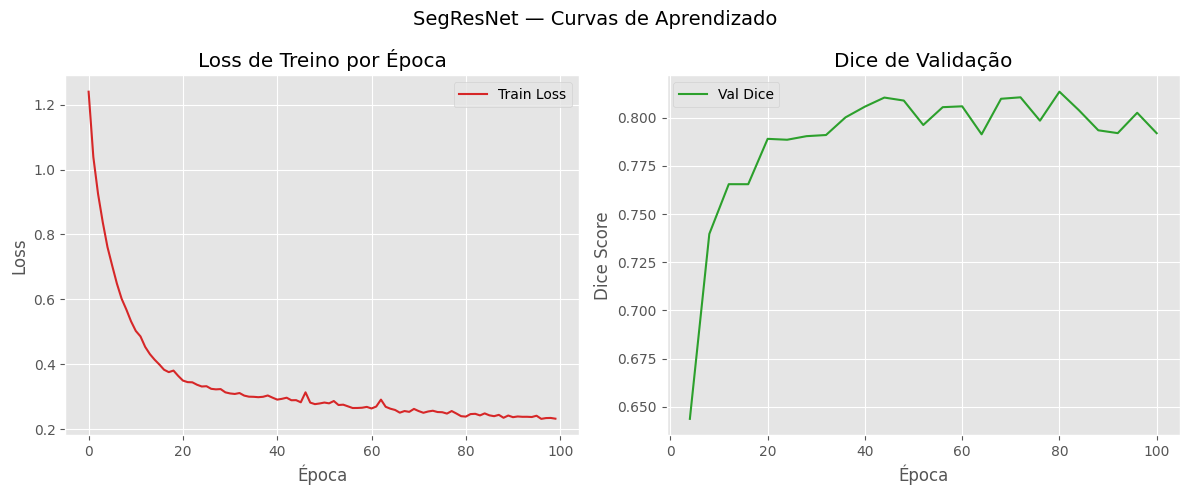

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Curva de Loss de Treino
ax1.plot(epoch_loss_values, label='Train Loss', color='tab:red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Loss de Treino por Época')
ax1.legend()

# Curva de Dice de Validação
val_epochs = [i * val_interval for i in range(1, len(metric_values) + 1)]
ax2.plot(val_epochs, metric_values, label='Val Dice', color='tab:green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Dice Score')
ax2.set_title('Dice de Validação')
ax2.legend()

plt.suptitle('SegResNet — Curvas de Aprendizado', fontsize=14)
plt.tight_layout()
plt.savefig('../models/segresnet_learning_curves.png', dpi=150)
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo
Carregamos o melhor checkpoint e calculamos métricas detalhadas por classe na base de validação:
- **Dice Score** por classe (NCR, ED, ET)
- **Hausdorff Distance 95** por classe (métrica oficial BraTS)
- **Sensitivity** e **Specificity** por classe

| Métrica | O que mede | Interpretação |
|---------|-----------|---------------|
| **Dice** | Sobreposição entre predição e gabarito | 0–1, maior = melhor |
| **HD95** | Hausdorff Distance 95th percentile — pior distância de fronteira | mm, menor = melhor |
| **Sensitivity** | % de voxels tumorais corretamente detectados | 0–1, maior = melhor |
| **Specificity** | % de voxels saudáveis corretamente identificados | 0–1, maior = melhor |


In [12]:
from monai.metrics import DiceMetric, HausdorffDistanceMetric, ConfusionMatrixMetric

# Carregar o melhor modelo salvo
best_model = SegResNet(
    in_channels=4,
    out_channels=4,
    init_filters=study.best_params['init_filters'],
    dropout_prob=0.2,
).to(device)
best_model.load_state_dict(torch.load(os.path.join('../models', 'best_metric_model_segresnet.pth'), weights_only=True))
print('Modelo SegResNet carregado com sucesso!')
best_model.eval()

# Métricas por classe
dice_per_class = DiceMetric(include_background=False, reduction="mean_batch")
hd95_per_class = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean_batch")
sensitivity_metric = ConfusionMatrixMetric(include_background=False, metric_name='sensitivity', reduction='mean_batch')
specificity_metric = ConfusionMatrixMetric(include_background=False, metric_name='specificity', reduction='mean_batch')

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data['image'].to(device)
        val_labels = val_data['label'].to(device)
        
        val_outputs = sliding_window_inference(
            inputs=val_inputs, roi_size=(96, 96, 96), sw_batch_size=4, predictor=best_model
        )
        
        val_outputs_list = [post_pred(i) for i in val_outputs]
        val_labels_list = [post_label(i) for i in val_labels]
        
        dice_per_class(y_pred=val_outputs_list, y=val_labels_list)
        hd95_per_class(y_pred=val_outputs_list, y=val_labels_list)
        sensitivity_metric(y_pred=val_outputs_list, y=val_labels_list)
        specificity_metric(y_pred=val_outputs_list, y=val_labels_list)

# Agregar resultados — ConfusionMatrixMetric retorna lista de tensores
# Agregar resultados
dice_scores = dice_per_class.aggregate()
hd95_scores = hd95_per_class.aggregate()
sens_raw = sensitivity_metric.aggregate()
spec_raw = specificity_metric.aggregate()

# ConfusionMatrixMetric com mean_batch retorna lista de tensores (cada um com C elementos)
# Flatten para 1D: ex: [tensor([a,b,c])] -> tensor([a,b,c])
def to_1d(x):
    if isinstance(x, list):
        x = torch.cat([t.flatten() for t in x])
    if isinstance(x, torch.Tensor) and x.dim() > 1:
        x = x.flatten()
    return x

sens_scores = to_1d(sens_raw)
spec_scores = to_1d(spec_raw)

class_names = ['NCR (TC)', 'ED (WT)', 'ET']
header = '{:<12} {:>8} {:>10} {:>8} {:>8}'.format('Classe', 'Dice', 'HD95', 'Sens', 'Spec')
print(header)
print('-' * 50)
for i, name in enumerate(class_names):
    d = dice_scores[i].item() if hasattr(dice_scores[i], 'item') else float(dice_scores[i])
    h = hd95_scores[i].item() if hasattr(hd95_scores[i], 'item') else float(hd95_scores[i])
    s = sens_scores[i].item() if i < len(sens_scores) else 0.0
    sp = spec_scores[i].item() if i < len(spec_scores) else 0.0
    print('{:<12} {:>8.4f} {:>10.2f} {:>8.4f} {:>8.4f}'.format(name, d, h, s, sp))
print('-' * 50)
mean_dice = dice_scores.mean().item() if hasattr(dice_scores, 'mean') else float(dice_scores)
mean_hd95 = hd95_scores.mean().item() if hasattr(hd95_scores, 'mean') else float(hd95_scores)
print('{:<12} {:>8.4f} {:>10.2f}'.format('Média', mean_dice, mean_hd95))

Modelo SegResNet carregado com sucesso!


/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/nics/Documentos/NeuroSegment-BraTS-MONAI/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered

Classe           Dice       HD95     Sens     Spec
--------------------------------------------------
NCR (TC)       0.7573       6.63   0.7985   0.9991
ED (WT)        0.8402       4.62   0.8990   0.9970
ET             0.8587       3.86   0.8903   0.9996
--------------------------------------------------
Média          0.8187       5.04
